# Predicting stocks returns with linear regression

## Import

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [126]:
import os
from time import time
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [3]:
sns.set_style('darkgrid')
idx = pd.IndexSlice

In [4]:
YEAR = 252

## Load Data

In [5]:
with pd.HDFStore(os.path.join('..', '..', 'data', 'assets.h5')) as store:
    data = (store['model_data']
            .dropna()
            .drop(['Open', 'Close', 'Low', 'High'], axis=1))

In [9]:
data.index.names = ['symbol', 'date']

In [11]:
data = data.drop([c for c in data.columns if 'lag' in c], axis = 1)

## Investment universe

In [12]:
data = data[data.peso_vol_rank < 100]

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 391307 entries, ('AGUAS-A.SN', Timestamp('2010-06-28 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-11-28 00:00:00'))
Data columns (total 59 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Volume                391307 non-null  float64
 1   peso_vol              391307 non-null  float64
 2   peso_vol_1m           391307 non-null  float64
 3   peso_vol_rank         391307 non-null  float64
 4   rsi                   391307 non-null  float64
 5   bb_high               391307 non-null  float64
 6   bb_low                391307 non-null  float64
 7   atr                   391307 non-null  float64
 8   macd                  391307 non-null  float64
 9   return_1d             391307 non-null  float64
 10  return_2d             391307 non-null  float64
 11  return_5d             391307 non-null  float64
 12  return_10d            391307 non-null  float64
 13  return_21d       

## Create model data

In [16]:
y = data.filter(like = 'target')
X = data.drop(y.columns, axis = 1)
X = X.drop(['peso_vol', 'peso_vol_rank', 'Volume'], axis = 1)

# Custom MultipleTimeSeriesCV

In [17]:
class MultipleTimeSeriesCV:
    """Generates tuples of train_idx, test_idx pairs
    Assumes the MultiIndex contains levels 'symbol' and 'date'
    purges overlapping outcomes"""

    def __init__(self,
                 n_splits=3,
                 train_period_length=126,
                 test_period_length=21,
                 lookahead=None,
                 shuffle=False):
        self.n_splits = n_splits
        self.lookahead = lookahead
        self.test_length = test_period_length
        self.train_length = train_period_length
        self.shuffle = shuffle

    def split(self, X, y=None, groups=None):
        unique_dates = X.index.get_level_values('date').unique()
        days = sorted(unique_dates, reverse=True)

        split_idx = []
        for i in range(self.n_splits):
            test_end_idx = i * self.test_length
            test_start_idx = test_end_idx + self.test_length
            train_end_idx = test_start_idx + +   self.lookahead - 1
            train_start_idx = train_end_idx + self.train_length + self.lookahead - 1
            split_idx.append([train_start_idx, train_end_idx,
                              test_start_idx, test_end_idx])

        dates = X.reset_index()[['date']]
        for train_start, train_end, test_start, test_end in split_idx:
            train_idx = dates[(dates.date > days[train_start])
                              & (dates.date <= days[train_end])].index
            test_idx = dates[(dates.date > days[test_start])
                             & (dates.date <= days[test_end])].index
            if self.shuffle:
                np.random.shuffle(list(train_idx))
            yield train_idx, test_idx

    def get_n_splits(self, X, y, groups=None):
        return self.n_splits

## Verify functionality

In [18]:
train_period_length = 63
test_period_length = 10
n_splits = int(3 * YEAR/test_period_length)
lookahead =1 

cv = MultipleTimeSeriesCV(n_splits=n_splits,
                          test_period_length=test_period_length,
                          lookahead=lookahead,
                          train_period_length=train_period_length)

In [ ]:
i = 0
for train_idx, test_idx in cv.split(X=data):
    train = data.iloc[train_idx]
    train_dates = train.index.get_level_values('date')
    test = data.iloc[test_idx]
    test_dates = test.index.get_level_values('date')
    df = pd.concat([train.reset_index(), test.reset_index()])
    n = len(df)
    assert n == len(df.drop_duplicates())
    print(train.groupby(level='symbol').size().value_counts().index[0],
          train_dates.min().date(), train_dates.max().date(),
          test.groupby(level='symbol').size().value_counts().index[0],
          test_dat es.min().date(), test_dates.max().date())
    i += 1
    if i == 10:
        break

63 2025-08-20 2025-11-14 10 2025-11-17 2025-11-28
63 2025-08-06 2025-10-31 10 2025-11-03 2025-11-14
63 2025-07-23 2025-10-17 10 2025-10-20 2025-10-31
63 2025-07-09 2025-10-03 10 2025-10-06 2025-10-17
63 2025-06-25 2025-09-19 10 2025-09-22 2025-10-03
63 2025-06-11 2025-09-05 10 2025-09-08 2025-09-19
63 2025-05-28 2025-08-22 10 2025-08-25 2025-09-05
63 2025-05-14 2025-08-08 10 2025-08-11 2025-08-22
63 2025-04-30 2025-07-25 10 2025-07-28 2025-08-08
63 2025-04-15 2025-07-11 10 2025-07-14 2025-07-25


## Visualization helper functions

### Prediction vs Actual scatter plot

In [21]:
def plot_preds_scatter(df, ticker=None):
    if ticker is not None:
        idx = pd.IndexSlice
        df = df.loc[idx[ticker, :], :]
    j = sns.jointplot(x='predicted', y='actuals',
                      robust=True, ci=None,
                      line_kws={'lw': 1, 'color': 'k'},
                      scatter_kws={'s': 1},
                      data=df,
                      kind='reg')
    j.ax_joint.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    j.ax_joint.xaxis.set_major_formatter(
        FuncFormatter(lambda x, _: '{:.1%}'.format(x)))
    j.ax_joint.set_xlabel('Predicted')
    j.ax_joint.set_ylabel('Actuals')

### Daily IC Distribution

In [22]:
def plot_ic_distribution(df, ax=None):
    if ax is not None:
        sns.distplot(df.ic, ax=ax)
    else:
        ax = sns.distplot(df.ic)
    mean, median = df.ic.mean(), df.ic.median()
    ax.axvline(0, lw=1, ls='--', c='k')
    ax.text(x=.05, y=.9,
            s=f'Mean: {mean:8.2f}\nMedian: {median:5.2f}',
            horizontalalignment='left',
            verticalalignment='center',
            transform=ax.transAxes)
    ax.set_xlabel('Information Coefficient')
    sns.despine()
    plt.tight_layout()

### Rolling Daily IC

In [23]:
def plot_rolling_ic(df):
    fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(14, 8))
    rolling_result = df.sort_index().rolling(21).mean().dropna()
    mean_ic = df.ic.mean()
    rolling_result.ic.plot(ax=axes[0],
                           title=f'Information Coefficient (Mean: {mean_ic:.2f})',
                           lw=1)
    axes[0].axhline(0, lw=.5, ls='-', color='k')
    axes[0].axhline(mean_ic, lw=1, ls='--', color='k')

    mean_rmse = df.rmse.mean()
    rolling_result.rmse.plot(ax=axes[1],
                             title=f'Root Mean Squared Error (Mean: {mean_rmse:.2%})',
                             lw=1,
                             ylim=(0, df.rmse.max()))
    axes[1].axhline(df.rmse.mean(), lw=1, ls='--', color='k')
    sns.despine()
    plt.tight_layout()

## Linear regression with sklearn

### Set up cross validation

In [70]:
train_period_length = 63
test_period_length = 10
n_splits = int(3 * YEAR / test_period_length)
lookahead = 1

cv = MultipleTimeSeriesCV(n_splits=n_splits,
                          test_period_length=test_period_length,
                          lookahead=lookahead,
                          train_period_length=train_period_length)

### Run cross validations with LinearRegression

In [71]:
%%time
target = f'target_{lookahead}d'
lr_predictions, lr_scores = [], []
lr = LinearRegression()
for i, (train_idx, test_idx) in enumerate(cv.split(X), 1):
    X_train, y_train, = X.iloc[train_idx], y[target].iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y[target].iloc[test_idx]
    lr.fit(X=X_train, y=y_train)
    y_pred = lr.predict(X_test)

    preds = y_test.to_frame('actuals').assign(predicted=y_pred)
    preds_by_day = preds.groupby(level='date')
    scores = pd.concat([preds_by_day.apply(lambda x: spearmanr(x.predicted,
                                                               x.actuals)[0] * 100)
                        .to_frame('ic'),
                        preds_by_day.apply(lambda x: np.sqrt(mean_squared_error(y_pred=x.predicted,
                                                                                y_true=x.actuals)))
                        .to_frame('rmse')], axis=1)

    lr_scores.append(scores)
    lr_predictions.append(preds)

lr_scores = pd.concat(lr_scores)
lr_predictions = pd.concat(lr_predictions)

CPU times: total: 3.36 s
Wall time: 3.22 s


### Persist results

In [82]:
lr_scores.to_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'lr/scores')
lr_predictions.to_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'lr/predictions')

In [83]:
lr_scores = pd.read_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'lr/scores')
lr_predictions = pd.read_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'lr/predictions')

### Evaluate results

In [74]:
lr_r, lr_p = spearmanr(lr_predictions.actuals, lr_predictions.predicted)
print(f'Information Coefficient (overall): {lr_r:.3%} (p-value: {lr_p:.4%})')

Information Coefficient (overall): 4.200% (p-value: 0.0000%)


### Prediction vs Actuals Scatter

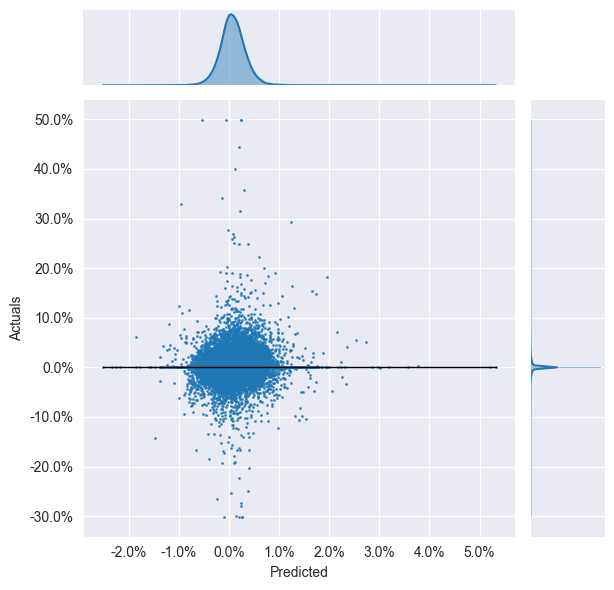

In [75]:
plot_preds_scatter(lr_predictions)

### Daily IC Distribution

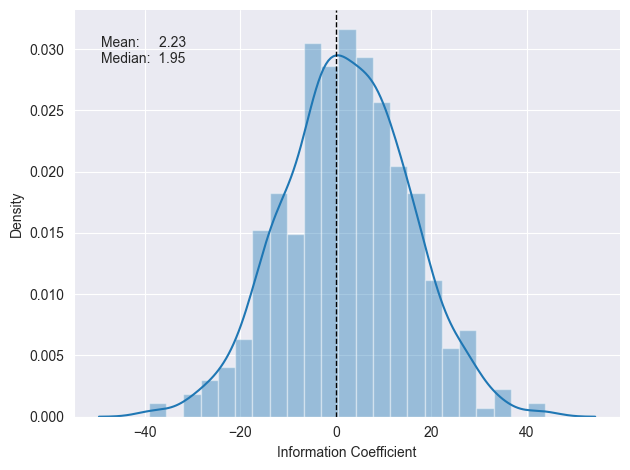

In [76]:
plot_ic_distribution(lr_scores)

### Rolling daily IC

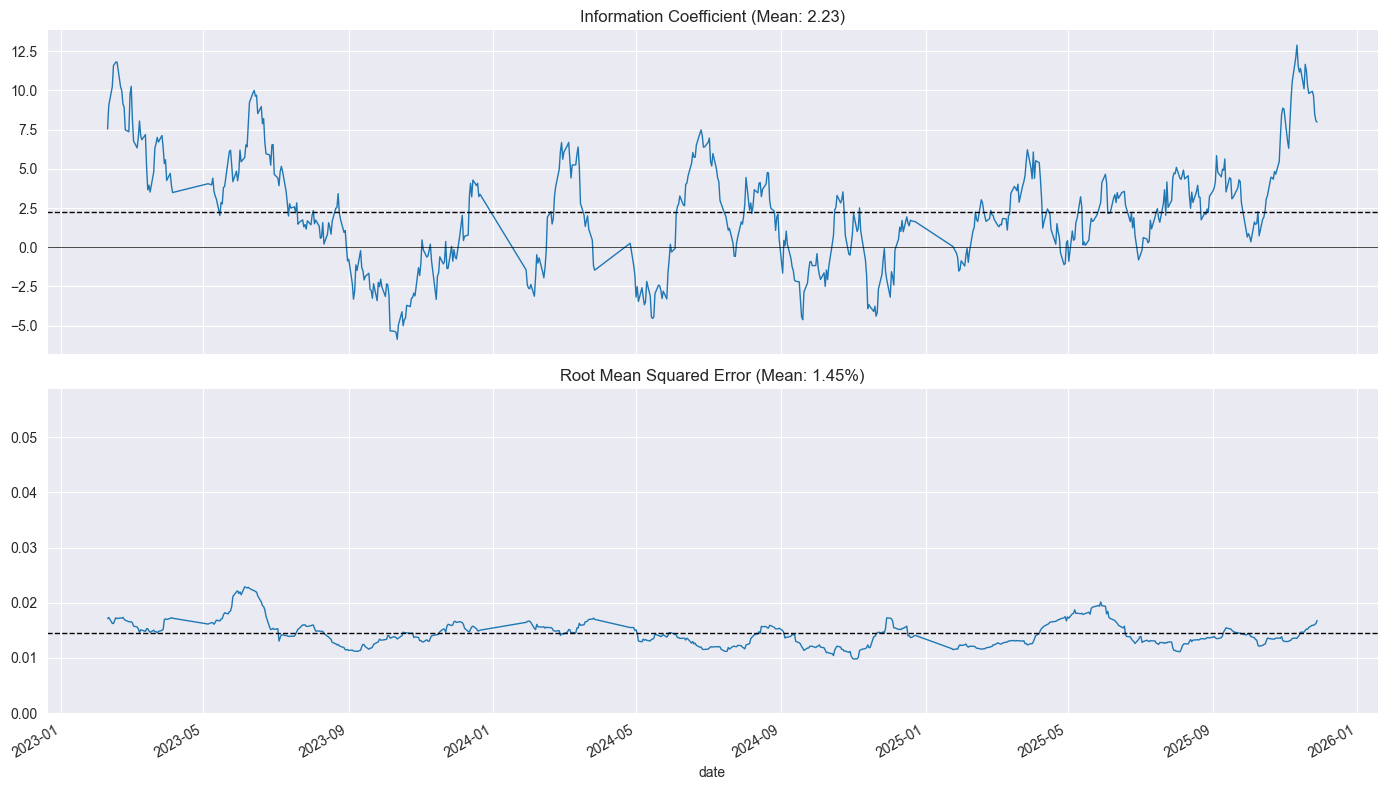

In [77]:
plot_rolling_ic(lr_scores)

## Ridge regression

### Define cross validation parameters

In [100]:
ridge_alphas = np.logspace(-2, 6, 10)
ridge_alphas = sorted(list(ridge_alphas) + list(ridge_alphas * 5))

In [101]:
n_splits = int(3 * YEAR/test_period_length)
train_period_length = 63
test_period_length = 10
lookahead = 1

cv = MultipleTimeSeriesCV(n_splits=n_splits,
                          test_period_length=test_period_length,
                          lookahead=lookahead,
                          train_period_length=train_period_length)

### Run cross validation

In [102]:
target = f'target_{lookahead}d'

X = X.drop([c for c in X.columns if 'year' in c], axis=1)

In [103]:
%%time
ridge_coeffs, ridge_scores, ridge_predictions = {}, [], []

for alpha in ridge_alphas:
    print(alpha, end=' ', flush=True)
    start = time()
    model = Ridge(alpha=alpha,
                  fit_intercept=False,
                  random_state=42)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)])

    coeffs = []
    for i, (train_idx, test_idx) in enumerate(cv.split(X), 1):
        X_train, y_train, = X.iloc[train_idx], y[target].iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y[target].iloc[test_idx]

        pipe.fit(X=X_train, y=y_train)
        y_pred = pipe.predict(X_test)

        preds = y_test.to_frame('actuals').assign(predicted=y_pred)
        preds_by_day = preds.groupby(level='date')
        scores = pd.concat([preds_by_day.apply(lambda x: spearmanr(x.predicted,
                                                                   x.actuals)[0] * 100)
                            .to_frame('ic'),
                            preds_by_day.apply(lambda x: np.sqrt(mean_squared_error(y_pred=x.predicted,
                                                                                    y_true=x.actuals)))
                            .to_frame('rmse')], axis=1)

        ridge_scores.append(scores.assign(alpha=alpha))
        ridge_predictions.append(preds.assign(alpha=alpha))

        coeffs.append(pipe.named_steps['model'].coef_)
    ridge_coeffs[alpha] = np.mean(coeffs, axis=0)

print('\n')

0.01 0.05 0.0774263682681127 0.38713184134056344 0.5994842503189409 2.9974212515947047 4.6415888336127775 23.20794416806389 35.93813663804626 179.6906831902313 278.2559402207126 1391.279701103563 2154.4346900318824 10772.173450159411 16681.005372000556 83405.02686000278 129154.96650148826 645774.8325074413 1000000.0 5000000.0 

CPU times: total: 58.5 s
Wall time: 59.1 s


### Persists results

In [104]:
ridge_scores = pd.concat(ridge_scores)
ridge_scores.to_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'ridge/scores')

ridge_coeffs = pd.DataFrame(ridge_coeffs, index=X.columns).T
ridge_coeffs.to_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'ridge/coeffs')

ridge_predictions = pd.concat(ridge_predictions)
ridge_predictions.to_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'ridge/predictions')

In [105]:
ridge_scores = pd.read_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'ridge/scores')
ridge_coeffs = pd.read_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'ridge/coeffs')
ridge_predictions = pd.read_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'ridge/predictions')

### Evaluate ridge results

In [106]:
ridge_r, ridge_p = spearmanr(ridge_predictions.actuals, ridge_predictions.predicted)
print(f'Information Coefficient (overall): {ridge_r:.3%} (p-value: {ridge_p:.4%})')

Information Coefficient (overall): 3.556% (p-value: 0.0000%)


In [107]:
ridge_scores.groupby('alpha').ic.describe()

,count,mean,std,min,25%,50%,75%,max
alpha,,,,,,,,
1.000000e-02,745.0,2.232084,13.096119,-39.146071,-5.877093,1.947696,10.942636,43.855052
5.000000e-02,745.0,2.232099,13.096181,-39.146071,-5.877093,1.947696,10.942636,43.855052
7.742637e-02,745.0,2.232456,13.095859,-39.146071,-5.877093,1.947696,10.942636,43.855052
3.871318e-01,745.0,2.233110,13.095833,-39.146071,-5.877093,1.947696,10.942636,43.855052
5.994843e-01,745.0,2.231943,13.095589,-39.146071,-5.877093,1.921740,10.942636,43.855052
2.997421e+00,745.0,2.237220,13.096007,-39.015376,-5.838519,1.944774,10.915084,43.980810
4.641589e+00,745.0,2.237015,13.097841,-39.057536,-5.856758,1.974101,10.899452,43.869168
2.320794e+01,745.0,2.242101,13.108336,-39.050509,-5.914558,1.957996,10.896532,43.703739
3.593814e+01,745.0,2.243378,13.104222,-38.967595,-5.855800,2.033382,10.859654,43.869168


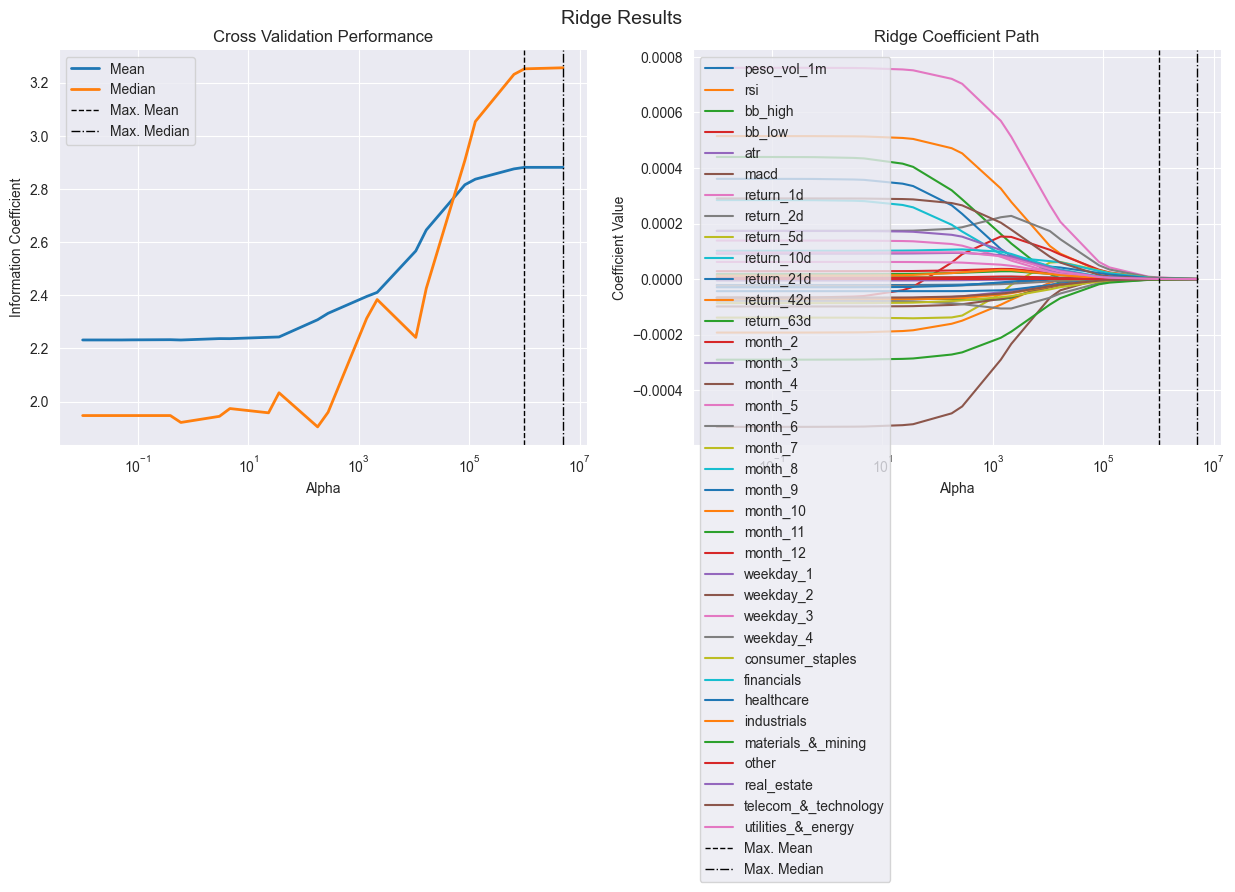

In [108]:
fig, axes = plt.subplots(ncols=2, sharex=True, figsize=(15, 5))

scores_by_alpha = ridge_scores.groupby('alpha').ic.agg(['mean', 'median'])
best_alpha_mean = scores_by_alpha['mean'].idxmax()
best_alpha_median = scores_by_alpha['median'].idxmax()

# Plot both mean and median consistently
scores_by_alpha['mean'].plot(logx=True,
                             ax=axes[0],
                             label='Mean',
                             lw=2)
scores_by_alpha['median'].plot(logx=True,
                               ax=axes[0],
                               label='Median',
                               lw=2)

axes[0].axvline(best_alpha_mean,
                ls='--',
                c='k',
                lw=1,
                label='Max. Mean')
axes[0].axvline(best_alpha_median,
                ls='-.',
                c='k',
                lw=1,
                label='Max. Median')
axes[0].legend()
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Information Coefficient')
axes[0].set_title('Cross Validation Performance')

ridge_coeffs.plot(logx=True,
                  legend=False,
                  ax=axes[1],
                  title='Ridge Coefficient Path')

axes[1].axvline(best_alpha_mean,
                ls='--',
                c='k',
                lw=1,
                label='Max. Mean')
axes[1].axvline(best_alpha_median,
                ls='-.',
                c='k',
                lw=1,
                label='Max. Median')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Coefficient Value')
axes[1].legend()

fig.suptitle('Ridge Results', fontsize=14)
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=.9)

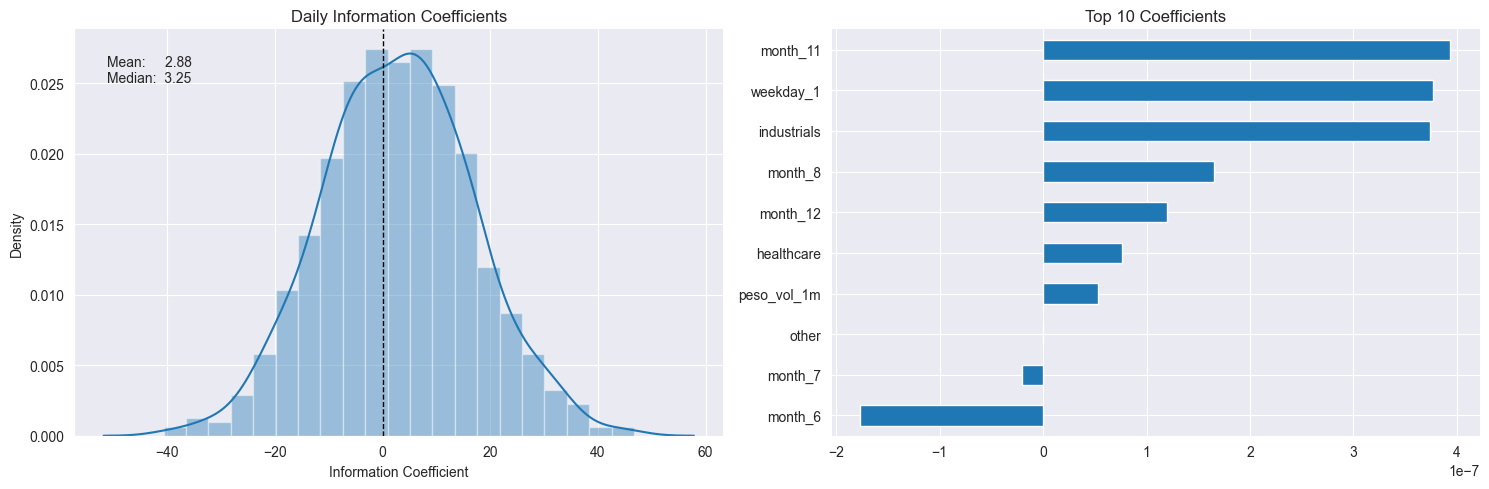

In [109]:
best_alpha = ridge_scores.groupby('alpha').ic.mean().idxmax()
fig, axes = plt.subplots(ncols=2, figsize=(15, 5))
plot_ic_distribution(ridge_scores[ridge_scores.alpha == best_alpha],
                     ax=axes[0])
axes[0].set_title('Daily Information Coefficients')
top_coeffs = ridge_coeffs.loc[best_alpha].abs().sort_values().head(10).index
top_coeffs.tolist()
ridge_coeffs.loc[best_alpha, top_coeffs].sort_values().plot.barh(ax=axes[1],
                                                                 title='Top 10 Coefficients')
sns.despine()
fig.tight_layout()

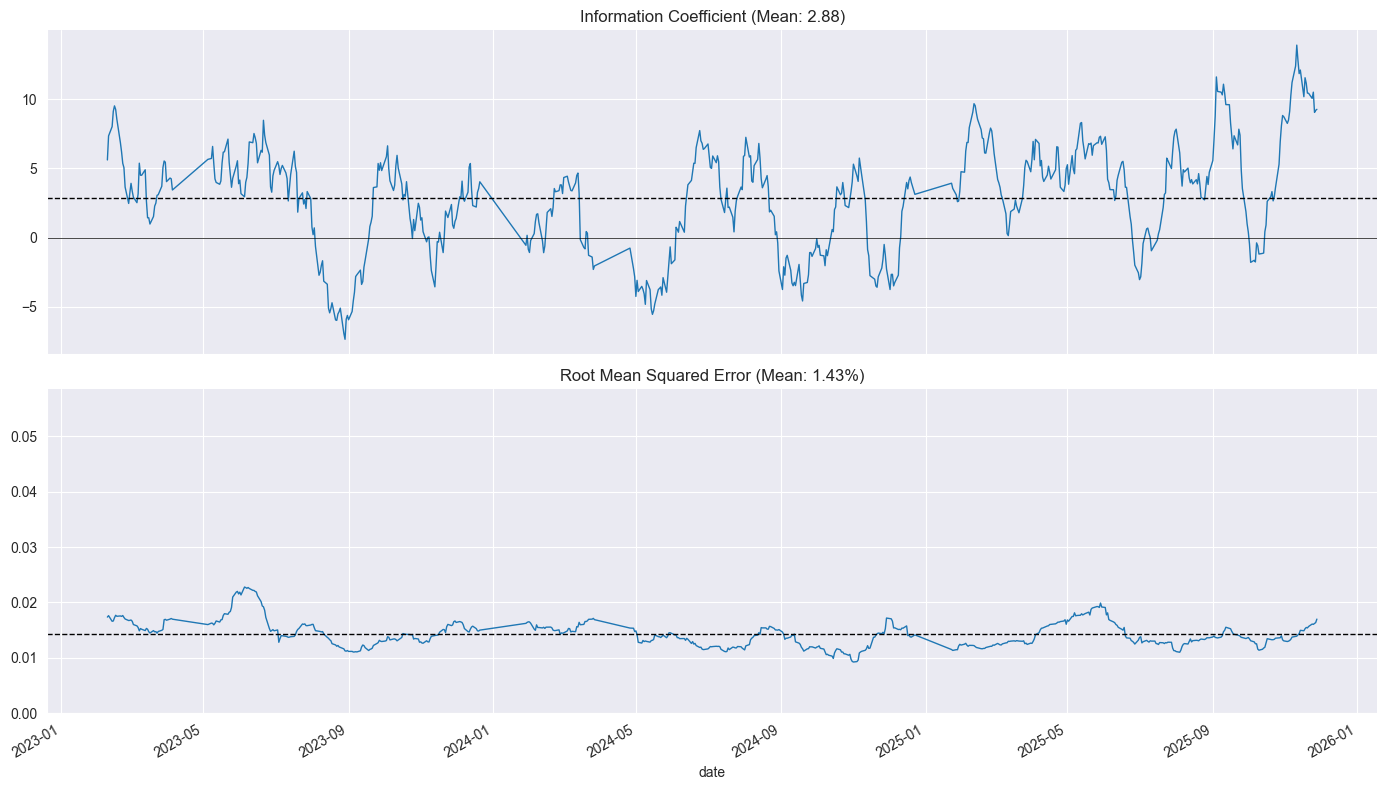

In [110]:
plot_rolling_ic(ridge_scores[ridge_scores.alpha==best_alpha])

## Lasso CV

### Define cross-validation parameters

In [177]:
lasso_alphas = np.logspace(-10, -3, 8)

In [178]:
train_period_length = 63
test_period_length = 10
YEAR = 252
n_splits = int(3 * YEAR / test_period_length) # three years
lookahead = 1

In [179]:
cv = MultipleTimeSeriesCV(n_splits=n_splits,
                          test_period_length=test_period_length,
                          lookahead=lookahead,
                          train_period_length=train_period_length)

### Run cross-validation with Lasso regression

In [180]:
target = f'target_{lookahead}d'

y = data.filter(like = 'target')
X = data.drop(y.columns, axis = 1)
X = X.drop(['peso_vol', 'peso_vol_rank', 'Volume'], axis = 1)

scaler = StandardScaler()
X = X.drop([c for c in X.columns if 'year' in c], axis=1)

In [181]:
binary_cols = [
    c for c in X.columns
    if X[c].dropna().isin([0, 1]).all()
]
cat_features = binary_cols

In [182]:
num_features = list(set(X.columns) - set(cat_features))

In [183]:
%%time

lasso_coeffs, lasso_scores, lasso_predictions = {}, [], []
for alpha in lasso_alphas:
    print(alpha, end=' ', flush=True)
    model = Lasso(alpha=alpha,
                  fit_intercept=False,  # StandardScaler centers data
                  random_state=42,
                  tol=1e-3,
                  max_iter=1000,
                  warm_start=True,
                  selection='random')

    preprocess = ColumnTransformer(
        transformers = [
            ('num', StandardScaler(), num_features),
            ('cat', 'passthrough', cat_features)
        ],
        remainder = 'drop'
    )

    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)])
    coeffs = []
    for i, (train_idx, test_idx) in enumerate(cv.split(X), 1):
        t = time()
        X_train, y_train, = X.iloc[train_idx], y[target].iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y[target].iloc[test_idx]

        pipe.fit(X=X_train, y=y_train)
        y_pred = pipe.predict(X_test)

        preds = y_test.to_frame('actuals').assign(predicted=y_pred)
        preds_by_day = preds.groupby(level='date')
        scores = pd.concat([preds_by_day.apply(lambda x: spearmanr(x.predicted,
                                                                   x.actuals)[0] * 100)
                            .to_frame('ic'),
                            preds_by_day.apply(lambda x: np.sqrt(mean_squared_error(y_pred=x.predicted,
                                                                                    y_true=x.actuals)))
                            .to_frame('rmse')],
                           axis=1)

        lasso_scores.append(scores.assign(alpha=alpha))
        lasso_predictions.append(preds.assign(alpha=alpha))

        coeffs.append(pipe.named_steps['model'].coef_)

    lasso_coeffs[alpha] = np.mean(coeffs, axis=0)

1e-10 1e-09 1e-08 1e-07 1e-06 1e-05 0.0001 0.001 CPU times: total: 31.2 s
Wall time: 31.8 s


### Persists results

In [184]:
lasso_scores = pd.concat(lasso_scores)
lasso_scores.to_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'lasso/scores')

lasso_coeffs = pd.DataFrame(lasso_coeffs, index=X.columns).T
lasso_coeffs.to_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'lasso/coeffs')

lasso_predictions = pd.concat(lasso_predictions)
lasso_predictions.to_hdf(os.path.join('..', '..', 'data', 'assets.h5'), 'lasso/predictions')

### Evaluate lasso results

In [185]:
best_alpha = lasso_scores.groupby('alpha').ic.mean().idxmax()
preds = lasso_predictions[lasso_predictions.alpha==best_alpha]

lasso_r, lasso_p = spearmanr(preds.actuals, preds.predicted)
print(f'Information Coefficient (overall): {lasso_r:.3%} (p-value: {lasso_p:.4%})')

Information Coefficient (overall): 4.980% (p-value: 0.0000%)


In [186]:
lasso_scores.groupby('alpha').ic.agg(['mean', 'median'])

,mean,median
alpha,,
1.000000e-10,2.194240,2.032623
1.000000e-09,2.193961,2.032623
1.000000e-08,2.193468,2.032623
1.000000e-07,2.193862,2.063308
1.000000e-06,2.210677,2.095932
1.000000e-05,2.226249,2.350716
1.000000e-04,2.570783,3.006268
1.000000e-03,4.199987,3.977721


### Lasso Coefficient path

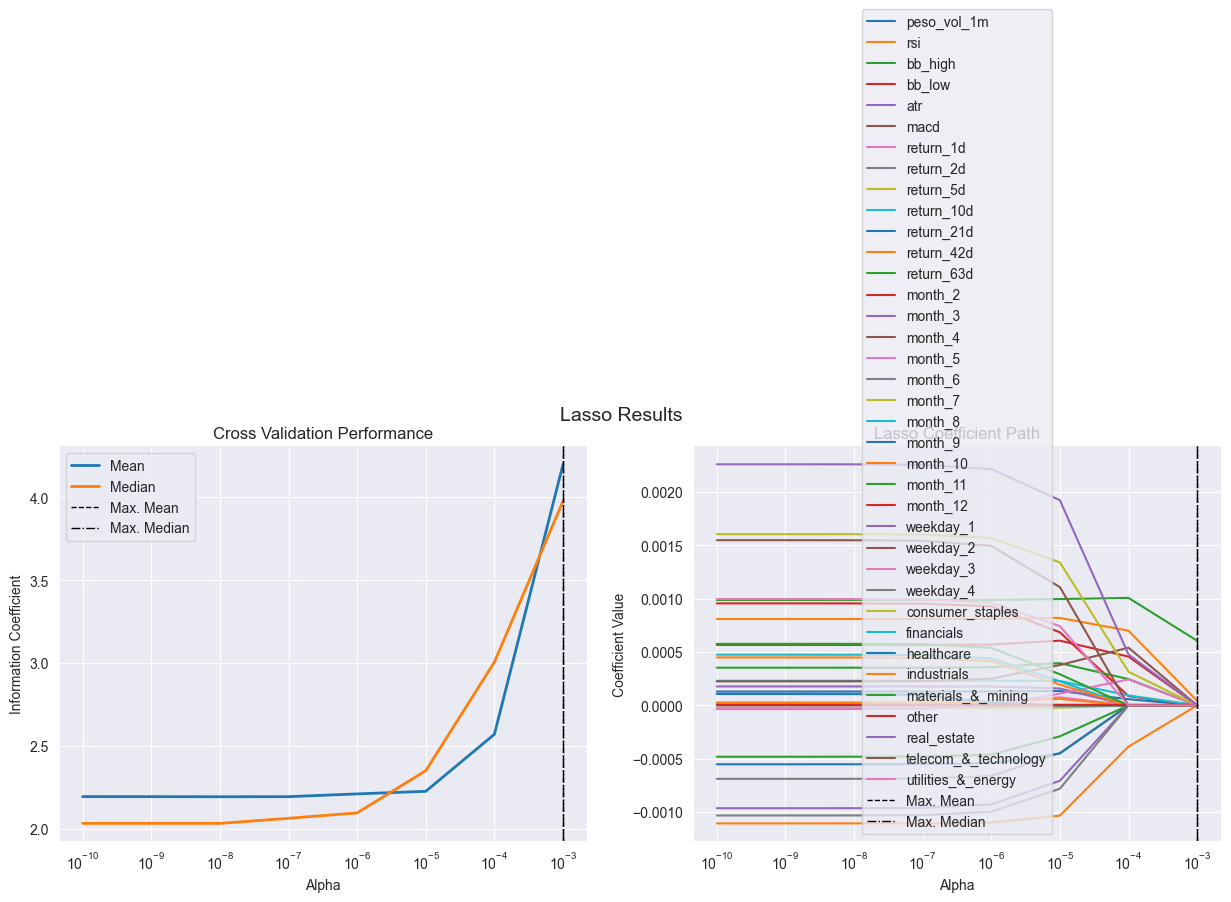

In [187]:
fig, axes = plt.subplots(ncols=2, sharex=True, figsize=(15, 5))

scores_by_alpha = lasso_scores.groupby('alpha').ic.agg(['mean', 'median'])
best_alpha_mean = scores_by_alpha['mean'].idxmax()
best_alpha_median = scores_by_alpha['median'].idxmax()

# Plot both mean and median consistently
scores_by_alpha['mean'].plot(logx=True,
                             ax=axes[0],
                             label='Mean',
                             lw=2)
scores_by_alpha['median'].plot(logx=True,
                               ax=axes[0],
                               label='Median',
                               lw=2)

axes[0].axvline(best_alpha_mean, ls='--', c='k', lw=1, label='Max. Mean')
axes[0].axvline(best_alpha_median, ls='-.', c='k', lw=1, label='Max. Median')
axes[0].legend()
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Information Coefficient')
axes[0].set_title('Cross Validation Performance')

lasso_coeffs.plot(logx=True, legend=False, ax=axes[1], title='Lasso Coefficient Path')
axes[1].axvline(best_alpha_mean, ls='--', c='k', lw=1, label='Max. Mean')
axes[1].axvline(best_alpha_median, ls='-.', c='k', lw=1, label='Max. Median')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Coefficient Value')
axes[1].legend()

fig.suptitle('Lasso Results', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=.9)
sns.despine()

### Lasso IC Distribution and Top 10 Features

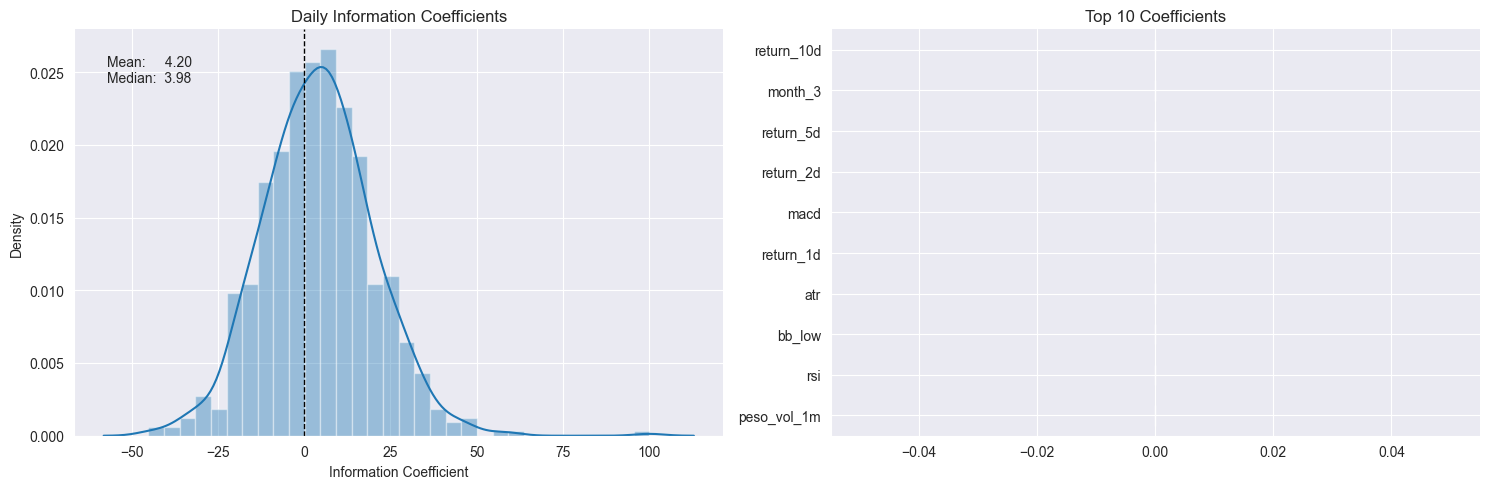

In [188]:
best_alpha = lasso_scores.groupby('alpha').ic.mean().idxmax()

fig, axes = plt.subplots(ncols=2, figsize=(15, 5))
plot_ic_distribution(lasso_scores[lasso_scores.alpha==best_alpha], ax=axes[0])
axes[0].set_title('Daily Information Coefficients')

top_coeffs = lasso_coeffs.loc[best_alpha].abs().sort_values().head(10).index
top_coeffs.tolist()
lasso_coeffs.loc[best_alpha, top_coeffs].sort_values().plot.barh(ax=axes[1], title='Top 10 Coefficients')

sns.despine()
fig.tight_layout();

## Compare results

In [189]:
best_ridge_alpha = ridge_scores.groupby('alpha').ic.mean().idxmax()
best_ridge_preds = ridge_predictions[ridge_predictions.alpha==best_ridge_alpha]
best_ridge_scores = ridge_scores[ridge_scores.alpha==best_ridge_alpha]

In [190]:
best_lasso_alpha = lasso_scores.groupby('alpha').ic.mean().idxmax()
best_lasso_preds = lasso_predictions[lasso_predictions.alpha==best_lasso_alpha]
best_lasso_scores = lasso_scores[lasso_scores.alpha==best_lasso_alpha]

In [191]:
df = pd.concat([lr_scores.assign(Model='Linear Regression'),
               best_ridge_scores.assign(Model='Ridge Regression'),
               best_lasso_scores.assign(Model='Lasso Regression')]).drop('alpha', axis=1)
df.columns = ['IC', 'RMSE', 'Model']

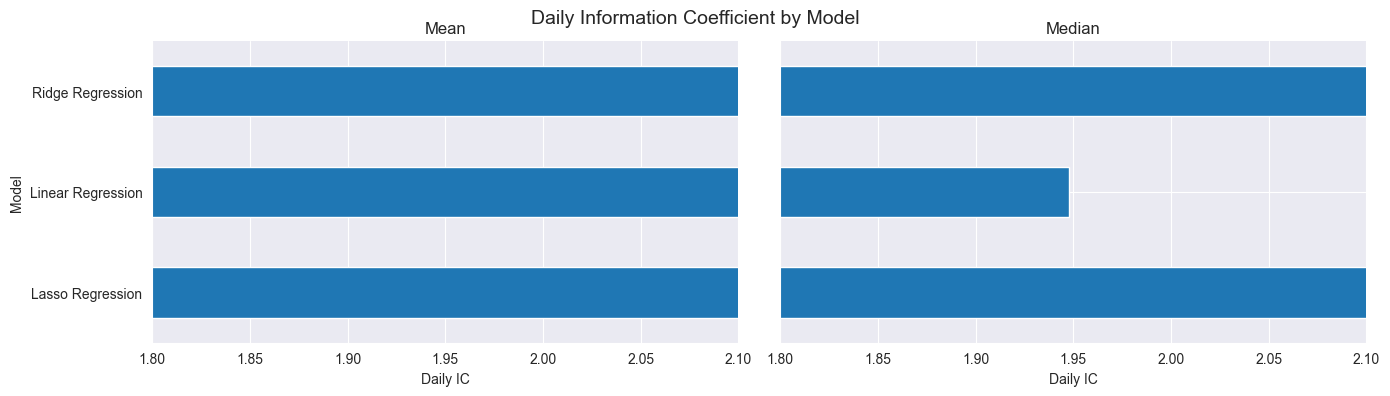

In [192]:
scores = df.groupby('Model').IC.agg(['mean', 'median'])
fig, axes = plt.subplots(ncols=2, figsize=(14,4), sharey=True, sharex=True)

scores['mean'].plot.barh(ax=axes[0], xlim=(1.85, 2), title='Mean')
scores['median'].plot.barh(ax=axes[1], xlim=(1.8, 2.1), title='Median')
axes[0].set_xlabel('Daily IC')
axes[1].set_xlabel('Daily IC')

fig.suptitle('Daily Information Coefficient by Model', fontsize=14)
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=.9)